In [13]:
import pandas as pd
import os
possible_paths = [
    '../data/raw/data/', 
    'data/raw/data/',     
    './data/raw/data/'
]

stock_data_path = None
for p in possible_paths:
    if os.path.exists(p):
        stock_data_path = p
        print(f"✅ Found data directory at: {p}")
        break

if not stock_data_path:
    print(f"❌ ERROR: Could not find the folder. Current working directory is: {os.getcwd()}")
else:
    def prepare_stock_data(directory):
        stocks_dict = {}
        
        files = [f for f in os.listdir(directory) if f.endswith('.csv')]
        print(f"📂 Found {len(files)} CSV files in {directory}...\n")
        
        for filename in files:
            ticker = filename.split('_')[0].upper()
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
                df.set_index('Date', inplace=True)
            
            if not isinstance(df.index, pd.DatetimeIndex):
                df.index = pd.to_datetime(df.index, utc=True, errors='coerce')

            df = df[df.index.notna()]
            
            cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            for col in cols:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df = df.sort_index()
            if isinstance(df.index, pd.DatetimeIndex) and df.isnull().values.any():
                df = df.interpolate(method='time').ffill().bfill()
            elif df.isnull().values.any():
                df = df.interpolate(method='linear').ffill().bfill()
            
            stocks_dict[ticker] = df
            print(f"📊 {ticker}: Cleaned and Indexed ({len(df)} rows).")
                
        return stocks_dict

    stocks_dict = prepare_stock_data(stock_data_path)
    
    if stocks_dict:
        test_ticker = list(stocks_dict.keys())[0]
        test_df = stocks_dict[test_ticker]
        print(f"\n--- 📋 Audit Report: {test_ticker} ---")
        print(f"Missing Values: {test_df.isnull().sum().sum()}")
        print(f"Index Type: {type(test_df.index)}") # This must say DatetimeIndex!

✅ Found data directory at: ../data/raw/data/
📂 Found 5 CSV files in ../data/raw/data/...

📊 AAPL.CSV: Cleaned and Indexed (3774 rows).
📊 AMZN.CSV: Cleaned and Indexed (3774 rows).
📊 GOOG.CSV: Cleaned and Indexed (3774 rows).
📊 META.CSV: Cleaned and Indexed (2923 rows).
📊 NVDA.CSV: Cleaned and Indexed (3774 rows).

--- 📋 Audit Report: AAPL.CSV ---
Missing Values: 0
Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
import pandas as pd
import numpy as np

print("--- 2. Computing Technical Indicators ---")

file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AAPL.csv" 
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.ffill().dropna()

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df_clean = df.dropna().copy()
print("✅ Math computed successfully! Here is the raw data:")
print(df_clean[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail())

--- 1. Computing Technical Indicators ---
✅ Math computed successfully! Here is the raw data:
                 Close      SMA_20     RSI_14      MACD
Date                                                   
2023-12-22  191.788757  191.856618  59.246127  2.633141
2023-12-26  191.243912  192.018094  49.031899  2.304751
2023-12-27  191.342972  192.154308  52.291510  2.029104
2023-12-28  191.768951  192.362839  47.920425  1.823998
2023-12-29  190.728775  192.490633  40.185234  1.559539


In [25]:

import pandas as pd
import numpy as np

print("--- 2. Computing Technical Indicators ---")

file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AMZN.csv" 
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.ffill().dropna()

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df_clean = df.dropna().copy()
print("✅ Math computed successfully! Here is the raw data:")
print(df_clean[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail())

--- 2. Computing Technical Indicators ---
✅ Math computed successfully! Here is the raw data:
                 Close      SMA_20     RSI_14      MACD
Date                                                   
2023-12-22  153.419998  148.578999  67.919790  3.135958
2023-12-26  153.410004  148.863000  64.901866  3.118650
2023-12-27  153.339996  149.178500  72.477032  3.063965
2023-12-28  153.380005  149.531499  68.786107  2.989395
2023-12-29  151.940002  149.824000  62.417575  2.782032


In [26]:
import pandas as pd
import numpy as np

print("--- 2. Computing Technical Indicators ---")

file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\GOOG.csv" 
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.ffill().dropna()

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df_clean = df.dropna().copy()
print("✅ Math computed successfully! Here is the raw data:")
print(df_clean[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail())

--- 2. Computing Technical Indicators ---
✅ Math computed successfully! Here is the raw data:
                 Close      SMA_20     RSI_14      MACD
Date                                                   
2023-12-22  141.750000  135.009596  74.016699  1.412015
2023-12-26  141.849304  135.246477  72.182037  1.706565
2023-12-27  140.478683  135.386520  70.915160  1.808553
2023-12-28  140.319748  135.628861  58.289315  1.855168
2023-12-29  139.972137  135.976979  63.741198  1.842820


In [27]:
import pandas as pd
import numpy as np

print("--- 2. Computing Technical Indicators ---")

file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\META.csv" 
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.ffill().dropna()

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df_clean = df.dropna().copy()
print("✅ Math computed successfully! Here is the raw data:")
print(df_clean[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail())

--- 2. Computing Technical Indicators ---
✅ Math computed successfully! Here is the raw data:
                 Close      SMA_20     RSI_14      MACD
Date                                                   
2023-12-22  351.224823  332.302945  77.739106  6.945367
2023-12-26  352.655975  333.303278  80.521321  7.436800
2023-12-27  355.637543  334.239505  82.554046  7.974921
2023-12-28  356.124634  335.537503  79.726508  8.344500
2023-12-29  351.791290  336.869788  70.564254  8.193282


In [28]:
import pandas as pd
import numpy as np

print("--- 2. Computing Technical Indicators ---")

file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\NVDA.csv" 
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.ffill().dropna()

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

df_clean = df.dropna().copy()
print("✅ Math computed successfully! Here is the raw data:")
print(df_clean[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail())

--- 2. Computing Technical Indicators ---
✅ Math computed successfully! Here is the raw data:
                Close     SMA_20     RSI_14      MACD
Date                                                 
2023-12-22  48.805527  47.706983  64.502633  0.634352
2023-12-26  49.254299  47.759019  62.503443  0.655689
2023-12-27  49.392231  47.838989  69.719854  0.675937
2023-12-28  49.497185  47.908266  66.371993  0.692470
2023-12-29  49.497185  48.046003  62.559209  0.697532


In [31]:
import pynance as pn
import numpy as np

print("---Computing Financial Metrics with PyNance ---")

if 'df' not in locals() or 'Close' not in df.columns:
    print("❌ ERROR: Dataframe 'df' not found. Please run your data loading cell first!")
else:
    try:
        df['Daily_Return'] = pn.tech.ret(df['Close'])
        print("✅ PyNance successfully computed daily returns.")
    except Exception as e:
        print(f"⚠️ PyNance error: {e}. Using Pandas fallback...")
        df['Daily_Return'] = df['Close'].pct_change()

    df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

    df['Volatility_21d'] = df['Daily_Return'].rolling(window=21).std() * np.sqrt(252)

    avg_return = df['Daily_Return'].mean()
    std_dev = df['Daily_Return'].std()
    sharpe_ratio = (avg_return / std_dev) * np.sqrt(252)

    df_clean = df.dropna().copy()

    print("✅ Financial Metrics Calculated Successfully!")
    print(f"📈 Overall Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    
    print("\n--- Sample of Financial Metrics ---")
    print(df_clean[['Close', 'Daily_Return', 'Cumulative_Return', 'Volatility_21d']].tail(5))

---Computing Financial Metrics with PyNance ---
⚠️ PyNance error: Too many indexers. Using Pandas fallback...
✅ Financial Metrics Calculated Successfully!
📈 Overall Annualized Sharpe Ratio: 1.03

--- Sample of Financial Metrics ---
                Close  Daily_Return  Cumulative_Return  Volatility_21d
Date                                                                  
2023-12-22  48.805527     -0.003266         243.453217        0.299818
2023-12-26  49.254299      0.009195         245.700993        0.292528
2023-12-27  49.392231      0.002800         246.391855        0.291087
2023-12-28  49.497185      0.002125         246.917539        0.288790
2023-12-29  49.497185      0.000000         246.917539        0.288305


In [23]:
import sys
print(sys.version)

3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]


--- Starting Ultimate Task 2 Pipeline ---
✅ Data successfully loaded.
✅ Technical Indicators calculated (Bypassing TA-Lib).
✅ Financial Metrics calculated.


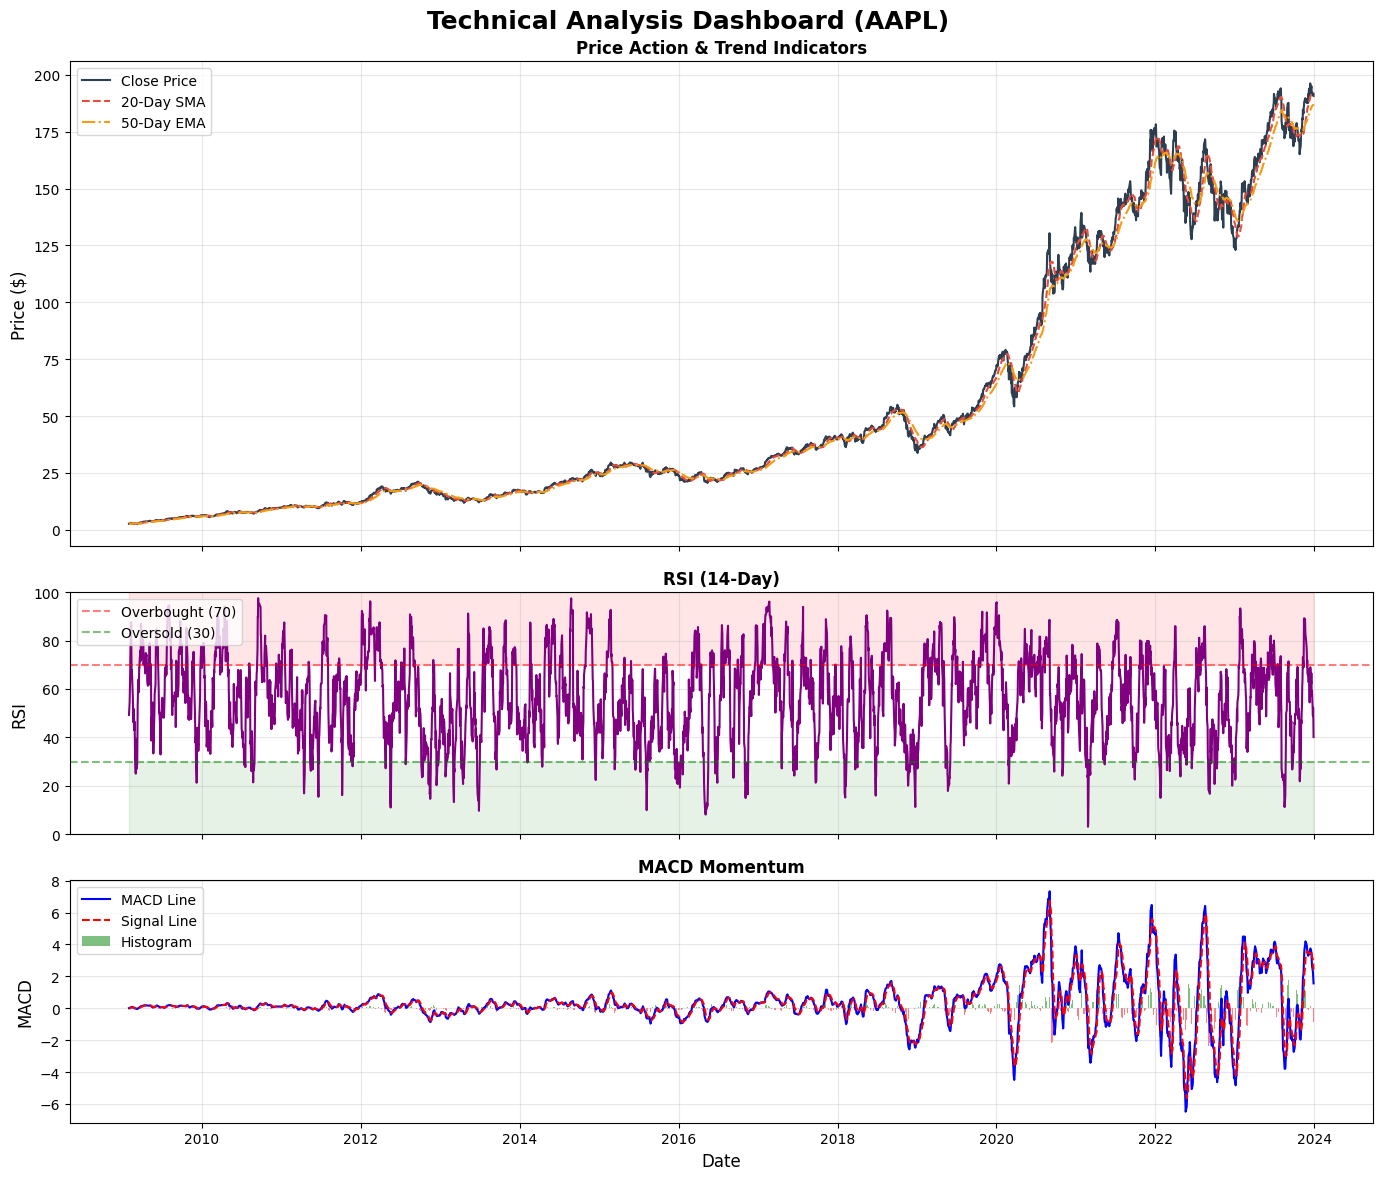

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Ultimate Task 2 Pipeline ---")


file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AAPL.csv" 

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df.set_index('Date', inplace=True)
    
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    df = df.ffill().dropna()
    print("✅ Data successfully loaded.")

    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    print("✅ Technical Indicators calculated (Bypassing TA-Lib).")

    
    df['Daily_Return'] = df['Close'].pct_change()
    df_clean = df.dropna().copy()
    print("✅ Financial Metrics calculated.")

 
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    fig.suptitle('Technical Analysis Dashboard (AAPL)', fontsize=18, fontweight='bold')

    ax1.plot(df_clean.index, df_clean['Close'], label='Close Price', color='#2c3e50')
    ax1.plot(df_clean.index, df_clean['SMA_20'], label='20-Day SMA', color='#e74c3c', ls='--')
    ax1.plot(df_clean.index, df_clean['EMA_50'], label='50-Day EMA', color='#f39c12', ls='-.')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title('Price Action & Trend Indicators', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    ax2.plot(df_clean.index, df_clean['RSI_14'], color='purple')
    ax2.axhline(70, color='red', ls='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(30, color='green', ls='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df_clean.index, 70, 100, color='red', alpha=0.1)
    ax2.fill_between(df_clean.index, 0, 30, color='green', alpha=0.1)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_title('RSI (14-Day)', fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.3)

    ax3.plot(df_clean.index, df_clean['MACD'], color='blue', label='MACD Line')
    ax3.plot(df_clean.index, df_clean['MACD_Signal'], color='red', ls='--', label='Signal Line')
    colors = ['green' if val >= 0 else 'red' for val in df_clean['MACD_Hist']]
    ax3.bar(df_clean.index, df_clean['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('MACD Momentum', fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ ERROR: Could not find dataset at '{file_path}'. Please check the path!")

--- Starting Ultimate Task 2 Pipeline ---
✅ Data successfully loaded.
✅ Technical Indicators calculated (Bypassing TA-Lib).
✅ Financial Metrics calculated.


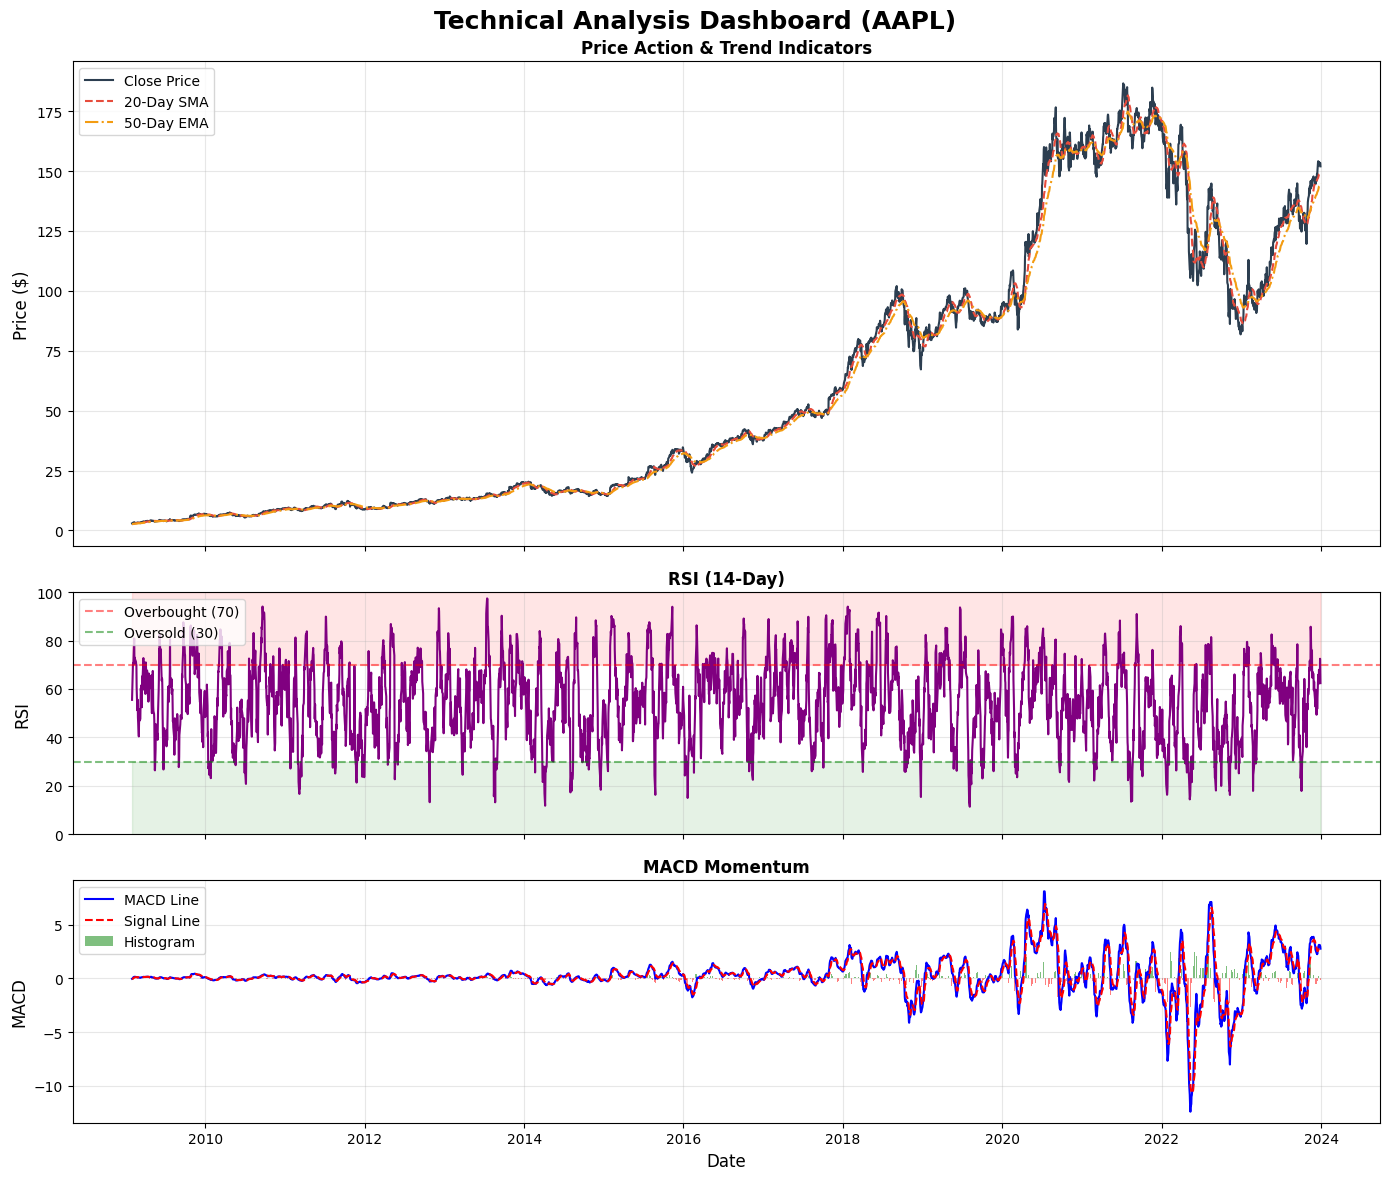

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Ultimate Task 2 Pipeline ---")


file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AMZN.csv" 

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df.set_index('Date', inplace=True)
    
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    df = df.ffill().dropna()
    print("✅ Data successfully loaded.")

    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    print("✅ Technical Indicators calculated (Bypassing TA-Lib).")

    
    df['Daily_Return'] = df['Close'].pct_change()
    df_clean = df.dropna().copy()
    print("✅ Financial Metrics calculated.")

 
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    fig.suptitle('Technical Analysis Dashboard (AAPL)', fontsize=18, fontweight='bold')

    ax1.plot(df_clean.index, df_clean['Close'], label='Close Price', color='#2c3e50')
    ax1.plot(df_clean.index, df_clean['SMA_20'], label='20-Day SMA', color='#e74c3c', ls='--')
    ax1.plot(df_clean.index, df_clean['EMA_50'], label='50-Day EMA', color='#f39c12', ls='-.')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title('Price Action & Trend Indicators', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    ax2.plot(df_clean.index, df_clean['RSI_14'], color='purple')
    ax2.axhline(70, color='red', ls='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(30, color='green', ls='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df_clean.index, 70, 100, color='red', alpha=0.1)
    ax2.fill_between(df_clean.index, 0, 30, color='green', alpha=0.1)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_title('RSI (14-Day)', fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.3)

    ax3.plot(df_clean.index, df_clean['MACD'], color='blue', label='MACD Line')
    ax3.plot(df_clean.index, df_clean['MACD_Signal'], color='red', ls='--', label='Signal Line')
    colors = ['green' if val >= 0 else 'red' for val in df_clean['MACD_Hist']]
    ax3.bar(df_clean.index, df_clean['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('MACD Momentum', fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ ERROR: Could not find dataset at '{file_path}'. Please check the path!")

--- Starting Ultimate Task 2 Pipeline ---
✅ Data successfully loaded.
✅ Technical Indicators calculated (Bypassing TA-Lib).
✅ Financial Metrics calculated.


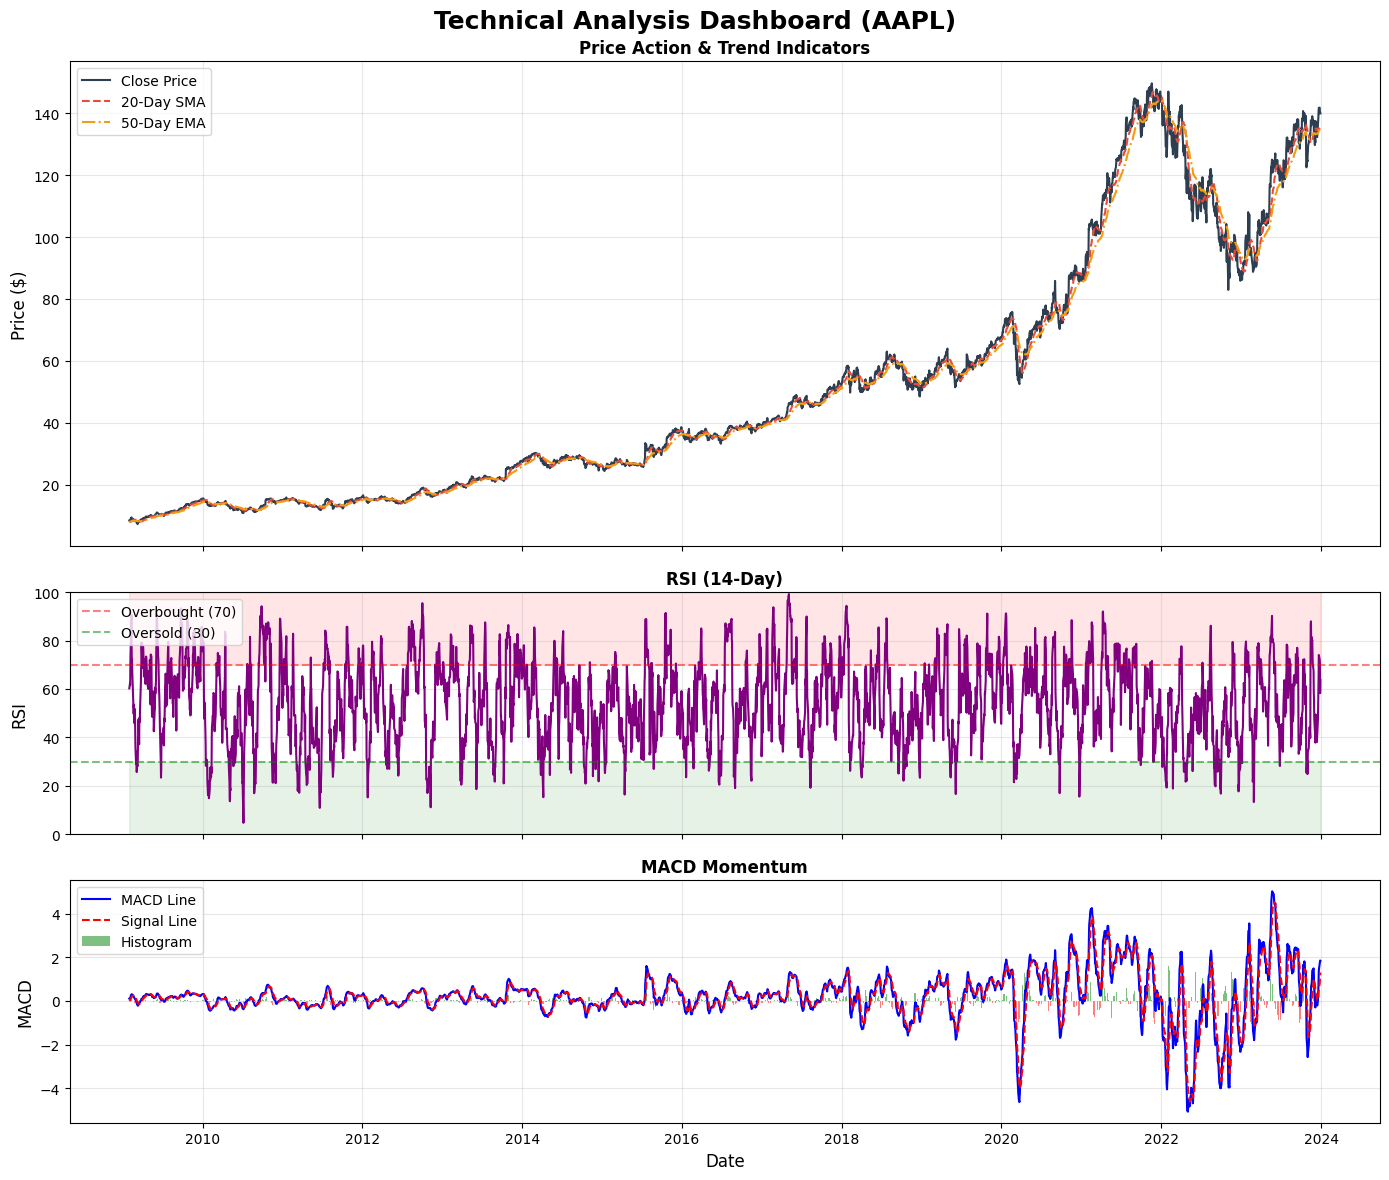

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Ultimate Task 2 Pipeline ---")


file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\GOOG.csv" 

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df.set_index('Date', inplace=True)
    
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    df = df.ffill().dropna()
    print("✅ Data successfully loaded.")

    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    print("✅ Technical Indicators calculated (Bypassing TA-Lib).")

    
    df['Daily_Return'] = df['Close'].pct_change()
    df_clean = df.dropna().copy()
    print("✅ Financial Metrics calculated.")

 
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    fig.suptitle('Technical Analysis Dashboard (AAPL)', fontsize=18, fontweight='bold')

    ax1.plot(df_clean.index, df_clean['Close'], label='Close Price', color='#2c3e50')
    ax1.plot(df_clean.index, df_clean['SMA_20'], label='20-Day SMA', color='#e74c3c', ls='--')
    ax1.plot(df_clean.index, df_clean['EMA_50'], label='50-Day EMA', color='#f39c12', ls='-.')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title('Price Action & Trend Indicators', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    ax2.plot(df_clean.index, df_clean['RSI_14'], color='purple')
    ax2.axhline(70, color='red', ls='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(30, color='green', ls='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df_clean.index, 70, 100, color='red', alpha=0.1)
    ax2.fill_between(df_clean.index, 0, 30, color='green', alpha=0.1)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_title('RSI (14-Day)', fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.3)

    ax3.plot(df_clean.index, df_clean['MACD'], color='blue', label='MACD Line')
    ax3.plot(df_clean.index, df_clean['MACD_Signal'], color='red', ls='--', label='Signal Line')
    colors = ['green' if val >= 0 else 'red' for val in df_clean['MACD_Hist']]
    ax3.bar(df_clean.index, df_clean['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('MACD Momentum', fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ ERROR: Could not find dataset at '{file_path}'. Please check the path!")

--- Starting Ultimate Task 2 Pipeline ---
✅ Data successfully loaded.
✅ Technical Indicators calculated (Bypassing TA-Lib).
✅ Financial Metrics calculated.


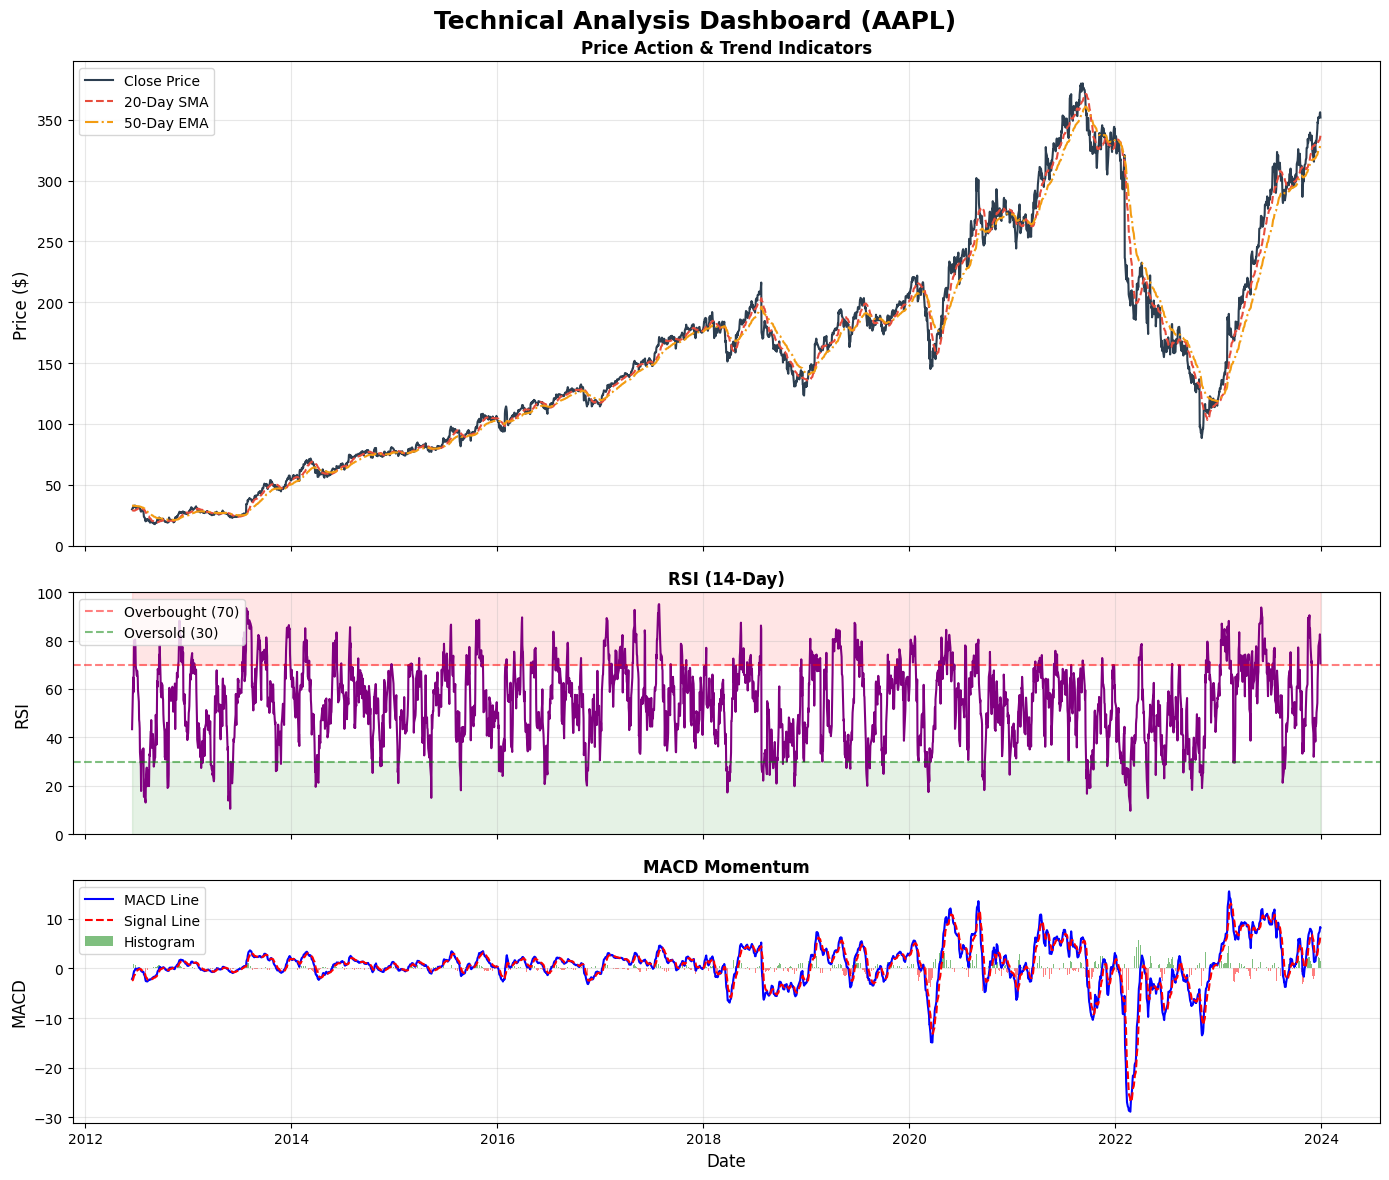

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Ultimate Task 2 Pipeline ---")


file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\META.csv" 

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df.set_index('Date', inplace=True)
    
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    df = df.ffill().dropna()
    print("✅ Data successfully loaded.")

    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    print("✅ Technical Indicators calculated (Bypassing TA-Lib).")

    
    df['Daily_Return'] = df['Close'].pct_change()
    df_clean = df.dropna().copy()
    print("✅ Financial Metrics calculated.")

 
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    fig.suptitle('Technical Analysis Dashboard (AAPL)', fontsize=18, fontweight='bold')

    ax1.plot(df_clean.index, df_clean['Close'], label='Close Price', color='#2c3e50')
    ax1.plot(df_clean.index, df_clean['SMA_20'], label='20-Day SMA', color='#e74c3c', ls='--')
    ax1.plot(df_clean.index, df_clean['EMA_50'], label='50-Day EMA', color='#f39c12', ls='-.')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title('Price Action & Trend Indicators', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    ax2.plot(df_clean.index, df_clean['RSI_14'], color='purple')
    ax2.axhline(70, color='red', ls='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(30, color='green', ls='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df_clean.index, 70, 100, color='red', alpha=0.1)
    ax2.fill_between(df_clean.index, 0, 30, color='green', alpha=0.1)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_title('RSI (14-Day)', fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.3)

    ax3.plot(df_clean.index, df_clean['MACD'], color='blue', label='MACD Line')
    ax3.plot(df_clean.index, df_clean['MACD_Signal'], color='red', ls='--', label='Signal Line')
    colors = ['green' if val >= 0 else 'red' for val in df_clean['MACD_Hist']]
    ax3.bar(df_clean.index, df_clean['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('MACD Momentum', fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ ERROR: Could not find dataset at '{file_path}'. Please check the path!")

--- Starting Ultimate Task 2 Pipeline ---
✅ Data successfully loaded.
✅ Technical Indicators calculated (Bypassing TA-Lib).
✅ Financial Metrics calculated.


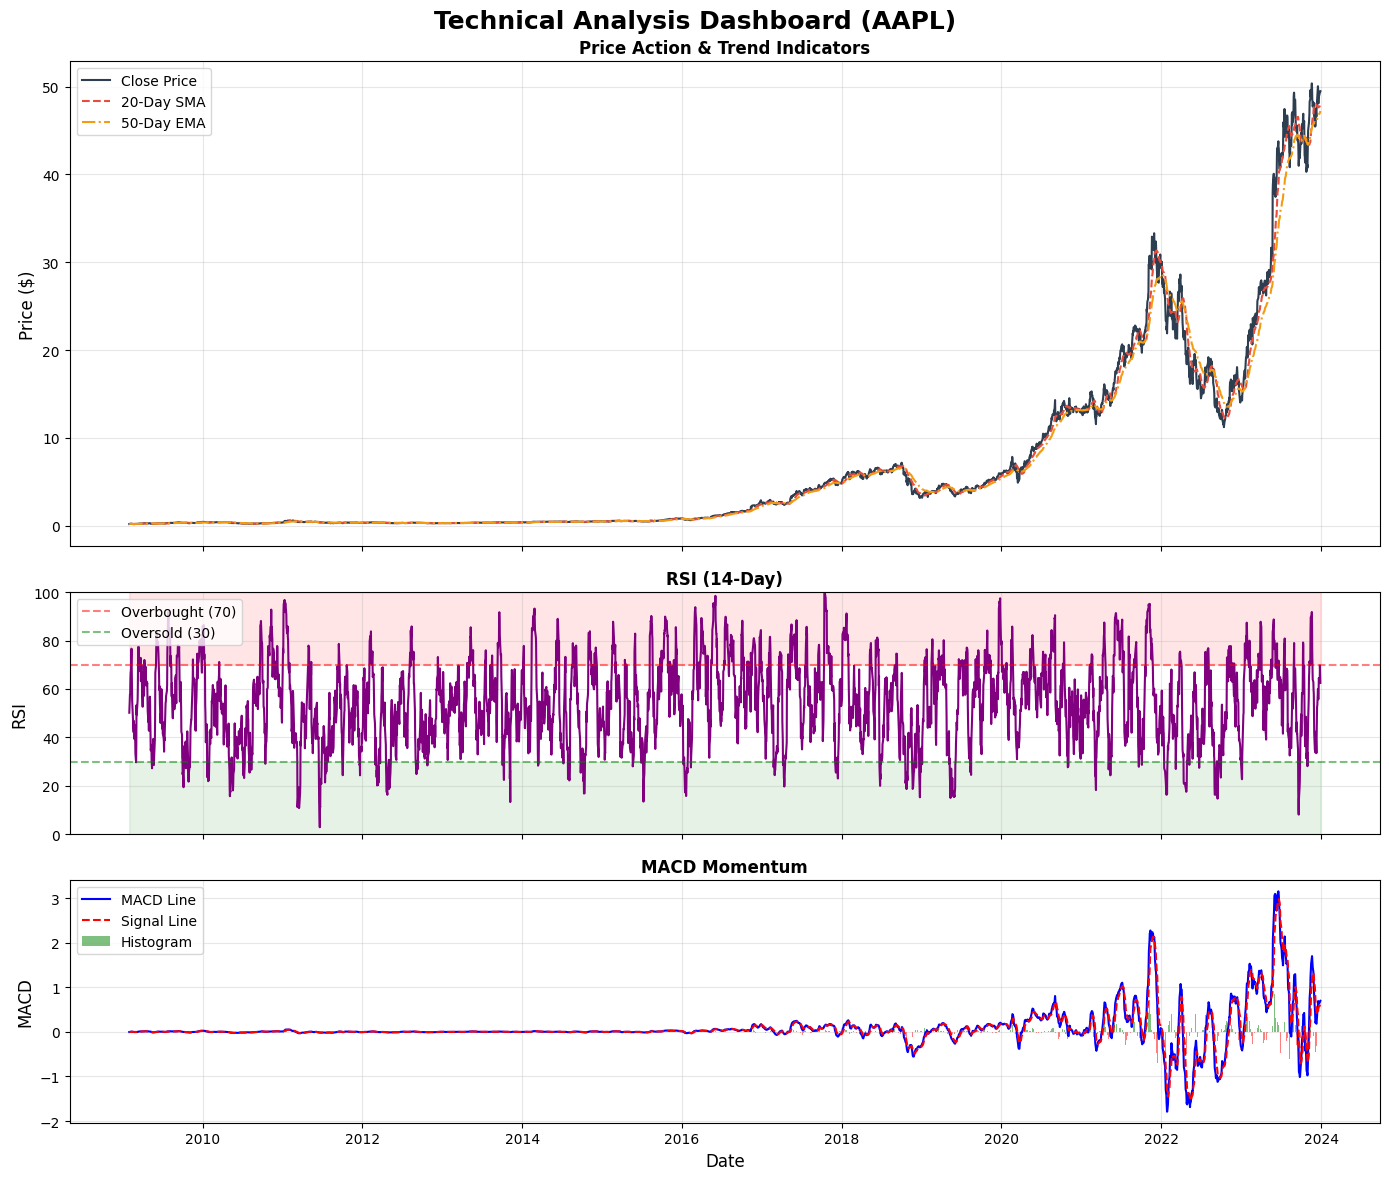

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Ultimate Task 2 Pipeline ---")


file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\NVDA.csv" 

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df.set_index('Date', inplace=True)
    
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    df = df.ffill().dropna()
    print("✅ Data successfully loaded.")

    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    print("✅ Technical Indicators calculated (Bypassing TA-Lib).")

    
    df['Daily_Return'] = df['Close'].pct_change()
    df_clean = df.dropna().copy()
    print("✅ Financial Metrics calculated.")

 
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    fig.suptitle('Technical Analysis Dashboard (AAPL)', fontsize=18, fontweight='bold')

    ax1.plot(df_clean.index, df_clean['Close'], label='Close Price', color='#2c3e50')
    ax1.plot(df_clean.index, df_clean['SMA_20'], label='20-Day SMA', color='#e74c3c', ls='--')
    ax1.plot(df_clean.index, df_clean['EMA_50'], label='50-Day EMA', color='#f39c12', ls='-.')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title('Price Action & Trend Indicators', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    ax2.plot(df_clean.index, df_clean['RSI_14'], color='purple')
    ax2.axhline(70, color='red', ls='--', alpha=0.5, label='Overbought (70)')
    ax2.axhline(30, color='green', ls='--', alpha=0.5, label='Oversold (30)')
    ax2.fill_between(df_clean.index, 70, 100, color='red', alpha=0.1)
    ax2.fill_between(df_clean.index, 0, 30, color='green', alpha=0.1)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_title('RSI (14-Day)', fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.3)

    ax3.plot(df_clean.index, df_clean['MACD'], color='blue', label='MACD Line')
    ax3.plot(df_clean.index, df_clean['MACD_Signal'], color='red', ls='--', label='Signal Line')
    colors = ['green' if val >= 0 else 'red' for val in df_clean['MACD_Hist']]
    ax3.bar(df_clean.index, df_clean['MACD_Hist'], color=colors, alpha=0.5, label='Histogram')
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('MACD Momentum', fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ ERROR: Could not find dataset at '{file_path}'. Please check the path!")